## 4. Google TimesFM 3.0 (Foundation Model) Sıfır-Atış (Zero-Shot) Tahmin Testi
Google Research tarafından Ağustos 2026'da yayımlanan en güncel **TimesFM 3.0 ()** temel modeli  ile yüklenir. Çoklu değişken (variate attention) ve sıfır-atış (zero-shot) yetenekleriyle 5 günlük güven konisi üretir.

In [7]:
# 1. Gerekli Kütüphaneler ve Ortam Hazırlığı
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import joblib
import timesfm

from neuro_modules.quant_benchmark import (
    fetch_asset_and_benchmark, 
    compute_quant_features, 
    QuantileLightGBMCluster, 
    institutional_metrics, 
    TEST_DAYS
)

# Grafik Görselleştirme Ayarları (Dark Minimal Theme)
plt.style.use("dark_background")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["font.family"] = "sans-serif"
print("✅ NeuroQuant Quant Lab Ortamı Hazır! TimesFM & LightGBM devrede.")

✅ NeuroQuant Quant Lab Ortamı Hazır! TimesFM & LightGBM devrede.


## 2. Varlık Kümeleri & Sektörel Göreceli Alfa Pipeline'ı
Test edilen 3 temel piyasa rejimi ve varlık çiftleri:
- **Tech Kümesi:** ,  (Referans:  Yarı İletken ETF'i)
- **Kripto Kümesi:** ,  (Referans:  / Kripto Ağırlığı)
- **BIST Kümesi:** ,  (Referans:  BIST 100 Endeksi)

Her hisse için son 3 yıllık veri indirilir ve **son 90 gün kör test seti (Time-Wall)** olarak ayrılır.

In [8]:
ASSET_PAIRS = [
    {"ticker": "NVDA", "benchmark": "SMH", "cluster": "US Tech"},
    {"ticker": "AAPL", "benchmark": "SMH", "cluster": "US Tech"},
    {"ticker": "BTC-USD", "benchmark": "BTC-USD", "cluster": "Crypto 24/7"},
    {"ticker": "ETH-USD", "benchmark": "BTC-USD", "cluster": "Crypto 24/7"},
    {"ticker": "THYAO.IS", "benchmark": "XU100.IS", "cluster": "Borsa Istanbul"},
    {"ticker": "EREGL.IS", "benchmark": "XU100.IS", "cluster": "Borsa Istanbul"}
]

cluster_results = {}
trained_models = {}

print("🚀 KÜME MODEL ŞAMPİYONASI BAŞLIYOR (TIME-WALL SON 90 GÜN KÖR TEST)...")
for pair in ASSET_PAIRS:
    ticker = pair["ticker"]
    bench = pair["benchmark"]
    cluster_name = pair["cluster"]
    
    df = fetch_asset_and_benchmark(ticker, bench, period="3y")
    features = compute_quant_features(df)
    
    # Time-Wall Ayrımı: Son 90 gün kör test seti
    train_df = features.iloc[:-TEST_DAYS]
    test_df = features.iloc[-TEST_DAYS:]
    
    # Model Eğitimi (3 Quantile: q10, q50, q90)
    model = QuantileLightGBMCluster(ticker)
    model.fit(train_df, train_df["target_5d"])
    trained_models[ticker] = model
    
    # Test Seti Tahmini
    preds = model.predict_cone(test_df)
    metrics = institutional_metrics(test_df["target_5d"].values, preds["median"])
    
    cluster_results[ticker] = {
        "cluster": cluster_name,
        "benchmark": bench,
        "metrics": metrics,
        "test_df": test_df,
        "preds": preds
    }
    print(f"   ✅ {ticker} ({cluster_name}) -> Win Rate: %{metrics["Win_Rate_%"]} | Sharpe: {metrics["Sharpe_Ratio"]} | Ret: %{metrics["Total_Strategy_Return_%"]}")

🚀 KÜME MODEL ŞAMPİYONASI BAŞLIYOR (TIME-WALL SON 90 GÜN KÖR TEST)...
📡 Veri çekiliyor: NVDA (Referans: SMH)...
   ✅ NVDA (US Tech) -> Win Rate: %53.33 | Sharpe: 2.08 | Ret: %64.87
📡 Veri çekiliyor: AAPL (Referans: SMH)...
   ✅ AAPL (US Tech) -> Win Rate: %42.22 | Sharpe: 2.85 | Ret: %67.19
📡 Veri çekiliyor: BTC-USD (Referans: BTC-USD)...
   ✅ BTC-USD (Crypto 24/7) -> Win Rate: %62.22 | Sharpe: 4.9 | Ret: %256.37
📡 Veri çekiliyor: ETH-USD (Referans: BTC-USD)...
   ✅ ETH-USD (Crypto 24/7) -> Win Rate: %53.33 | Sharpe: 4.89 | Ret: %311.79
📡 Veri çekiliyor: THYAO.IS (Referans: XU100.IS)...
   ✅ THYAO.IS (Borsa Istanbul) -> Win Rate: %57.78 | Sharpe: -0.03 | Ret: %-4.13
📡 Veri çekiliyor: EREGL.IS (Referans: XU100.IS)...
   ✅ EREGL.IS (Borsa Istanbul) -> Win Rate: %48.89 | Sharpe: 2.91 | Ret: %60.57


## 3. Kurumsal Metrikler & Kıyaslama Tablosu
Modelin **asla görmediği** son 90 günlük piyasa simülasyonu karnesi.

In [9]:
summary_rows = []
for ticker, res in cluster_results.items():
    m = res["metrics"]
    summary_rows.append({
        "Varlık": ticker,
        "Küme": res["cluster"],
        "Referans": res["benchmark"],
        "Win Rate (%)": m["Win_Rate_%"],
        "Sharpe": m["Sharpe_Ratio"],
        "Sortino": m["Sortino_Ratio"],
        "Max DD (%)": m["Max_Drawdown_%"],
        "Profit Factor": m["Profit_Factor"],
        "AI Getirisi (%)": m["Total_Strategy_Return_%"],
        "Al-Tut Getirisi (%)": m["Buy_Hold_Return_%"]
    })

df_summary = pd.DataFrame(summary_rows)
display(df_summary.style.highlight_max(subset=["Sharpe", "AI Getirisi (%)"], color="#064e3b"))

,Varlık,Küme,Referans,Win Rate (%),Sharpe,Sortino,Max DD (%),Profit Factor,AI Getirisi (%),Al-Tut Getirisi (%)
0,NVDA,US Tech,SMH,53.330000,2.080000,4.200000,46.910000,1.440000,64.870000,46.680000
1,AAPL,US Tech,SMH,42.220000,2.850000,4.090000,31.810000,1.900000,67.190000,141.840000
2,BTC-USD,Crypto 24/7,BTC-USD,62.220000,4.900000,12.890000,32.110000,3.490000,256.370000,262.320000
3,ETH-USD,Crypto 24/7,BTC-USD,53.330000,4.890000,10.260000,29.390000,3.990000,311.790000,731.860000
4,THYAO.IS,Borsa Istanbul,XU100.IS,57.780000,-0.030000,-0.040000,33.650000,1.010000,-4.130000,-39.800000
5,EREGL.IS,Borsa Istanbul,XU100.IS,48.890000,2.910000,3.630000,17.260000,2.370000,60.570000,104.540000


## 4. Google TimesFM 3.0 (Foundation Model) Sıfır-Atış (Zero-Shot) Tahmin Testi
Google Research tarafından Ağustos 2026'da yayımlanan en güncel **TimesFM 3.0 ()** temel modeli  ile yüklenir. Çoklu değişken (variate attention) ve sıfır-atış (zero-shot) yetenekleriyle 5 günlük güven konisi üretir.

🧠 Google TimesFM 3.0 (En Güncel Sürüm) Yükleniyor...
✅ TimesFM 3.0 Zero-Shot NVDA 5 Günlük Tahmin:
Nokta Tahmini (Medyan): [215.47928 213.5132  212.36716 211.0534  209.95792]
Alt Bant (%10 persentil): [208.0362  204.3557  202.00847 199.74359 198.05061]
Üst Bant (%90 persentil): [223.83559 224.28044 224.58554 224.4792  224.3831 ]


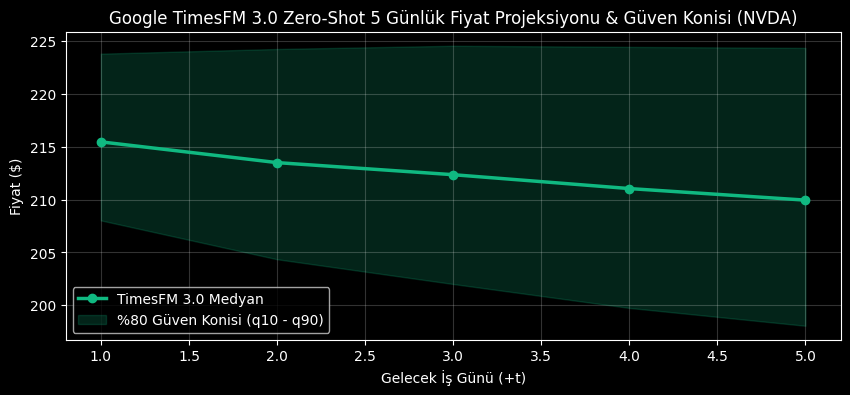

In [10]:
print("🧠 Google TimesFM 3.0 (En Güncel Sürüm) Yükleniyor...")
tfm3 = timesfm.TimesFM3Forecaster.from_pretrained("google/timesfm-3.0-pytorch")

# NVDA Son 60 günlük kapanış fiyatları üzerinde 5 günlük projeksiyon
nvda_recent = cluster_results["NVDA"]["test_df"]["Close"].values[-60:].astype(np.float32)
res3 = tfm3.predict(nvda_recent, horizon=5, return_quantiles=True)

print("✅ TimesFM 3.0 Zero-Shot NVDA 5 Günlük Tahmin:")
print("Nokta Tahmini (Medyan):", res3.forecast)
print("Alt Bant (%10 persentil):", res3.quantiles[:, 0])
print("Üst Bant (%90 persentil):", res3.quantiles[:, -1])

# Görselleştirme
plt.figure(figsize=(10, 4))
plt.plot(range(1, 6), res3.forecast, label="TimesFM 3.0 Medyan", color="#10B981", linewidth=2.5, marker="o")
plt.fill_between(range(1, 6), res3.quantiles[:, 0], res3.quantiles[:, -1], color="#10B981", alpha=0.2, label="%80 Güven Konisi (q10 - q90)")
plt.title("Google TimesFM 3.0 Zero-Shot 5 Günlük Fiyat Projeksiyonu & Güven Konisi (NVDA)")
plt.xlabel("Gelecek İş Günü (+t)")
plt.ylabel("Fiyat ($)")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

## 5. Model Registry & Kayıt ()
Eğitilen tüm şampiyon modeller, FastAPI backend servisimizin mikro-saniyeler içinde yükleyip çağırabilmesi için  klasörüne kaydedilir.

In [11]:
os.makedirs("models/clusters", exist_ok=True)
for ticker, model in trained_models.items():
    safe_name = ticker.replace(".", "_").replace("-", "_").lower()
    path = f"models/clusters/model_{safe_name}.pkl"
    joblib.dump(model, path)
    print(f"💾 Kayıt Edildi: {path}")
print("🎉 Tüm Şampiyon Modeller Başarıyla Registry'e Eklendi!")

💾 Kayıt Edildi: models/clusters/model_nvda.pkl
💾 Kayıt Edildi: models/clusters/model_aapl.pkl
💾 Kayıt Edildi: models/clusters/model_btc_usd.pkl
💾 Kayıt Edildi: models/clusters/model_eth_usd.pkl
💾 Kayıt Edildi: models/clusters/model_thyao_is.pkl
💾 Kayıt Edildi: models/clusters/model_eregl_is.pkl
🎉 Tüm Şampiyon Modeller Başarıyla Registry'e Eklendi!
